# Appendix — Page-feature diagnostics for the ten writing features behind Figures 11–13

This notebook is self-contained and reproducible (`jupyter nbconvert --to notebook --execute --inplace appendix.ipynb`).
It documents the **union of writing features** that appear across **Figures 11–13** — the "write for citation" support
levers (Figure 11), the page-length lever (Figure 12), and the re-citation "stickiness" levers (Figure 13) — and emits
three appendix artefacts:

- **A.** Operational definitions of all ten features, exactly as implemented in `scripts/build_page_features.py`.
- **B.** An excerpt of cited pages with their **raw** (un-standardised) feature values plus both citation outcomes
  (clearly-supported share and re-citation rate), chosen to span the feature ranges.
- **C.** The 10×10 **Spearman** correlation matrix across all cited-page events, as a Word-ready table and a heatmap.

**Analysis set.** There are **58,851** total citation events, but page-writing features can only be measured on pages
with fetchable text, so this analysis uses the **47,852 text-bearing cited pages** (`has_text == 1`); the other
**10,999 (18.7%)** have no fetchable text — the features are undefined there — and are excluded, matching the
page-feature models in `page_features.ipynb`.

**Outcomes.** *Clearly-supported share* is the per-event faithful-citation outcome (NLI entailment ≥ 0.50). *Re-citation
rate* is the Figure 13 stickiness outcome — the share of the k = 8 repeats in which a page cited once for a query is cited
again — defined at the (page, engine, query) level; Gemini is excluded from it (its per-response redirect URLs make page
identity unobservable), so Gemini rows show "—".

**Feature labels.** Most map directly by display label; `avg_word_len` is reported as *vocabulary density*,
`log1p_n_words` as *page length* (log word count), and `caps_mid_share` as *entity density*.

In [1]:
# === Appendix preamble: style, data, raw-feature reconstruction (10-feature union), validators ===
import os, re, warnings, logging, numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
warnings.filterwarnings("ignore"); logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# --- style (Visual_Style_Guide §13 subset) ---
mpl.rcParams["font.family"] = "sans-serif"; mpl.rcParams["font.sans-serif"] = ["Calibri", "DejaVu Sans", "Arial"]
mpl.rcParams["font.size"] = 11
mpl.rcParams["figure.dpi"] = 300; mpl.rcParams["savefig.dpi"] = 300
mpl.rcParams["savefig.bbox"] = "tight"; mpl.rcParams["savefig.pad_inches"] = 0.15
CMAP_SEQ = LinearSegmentedColormap.from_list("teal_seq", ["#EAF0F7", "#1F4E79"])   # appendix heatmap ramp

# --- locate repo root (thesis_config.py marker) and resolve paths ---
ROOT = next(p for p in [os.getcwd()] + [os.path.abspath(os.path.join(os.getcwd(), *[".."] * i)) for i in (1, 2, 3)]
            if os.path.exists(os.path.join(p, "thesis_config.py")))
PF_DIR = os.path.join(ROOT, "analysis/page_features")
QDIR   = os.path.join(ROOT, "data/scaleup/queries")
FIG_DIR = os.path.join(ROOT, "figures/scaleup"); os.makedirs(FIG_DIR, exist_ok=True)

# --- the ten Figures 11-13 features: code column -> sentence-case label ---
FEATS = ["lead_query_coverage", "title_query_jaccard", "title_is_question", "title_listicle", "title_len_words",
         "avg_word_len", "digits_per_100w", "log1p_n_words", "caps_mid_share", "has_recent_year"]
LAB = {"lead_query_coverage": "Lead query coverage", "title_query_jaccard": "Title–query word overlap",
       "title_is_question": "Question-style title", "title_listicle": "Listicle-style title",
       "title_len_words": "Title length", "avg_word_len": "Vocabulary density",
       "digits_per_100w": "Digit tokens per 100 words", "log1p_n_words": "Page length",
       "caps_mid_share": "Entity density", "has_recent_year": "2024+ year mention"}

# --- data: standardized model frame (analysis set) + raw page features + queries + re-citation frame ---
M  = pd.read_parquet(os.path.join(PF_DIR, "model_frame_events.parquet"))   # 47,852 cited-page events (has_text)
UF = pd.read_parquet(os.path.join(PF_DIR, "url_features.parquet"))          # raw page-level features by URL
QF = pd.read_parquet(os.path.join(QDIR, "reclass_queries.parquet"))
ST = pd.read_parquet(os.path.join(PF_DIR, "model_frame_sticky.parquet"))    # re-citation (stickiness); excludes Gemini
N_TOTAL = len(pd.read_parquet(os.path.join(PF_DIR, "citation_events.parquet")))   # 58,851 total citation events

# --- reconstruct the ten features RAW (un-standardised) at the event level, matching build_page_features.py ---
RE_WORD = re.compile(r"[A-Za-z]+")
STOP = set("the a an and or of to in for on with is are was were be been at by from as it this that".split())
QTOK = {r.query_id: set(w.lower() for w in RE_WORD.findall(r.query_text)) - STOP for r in QF.itertuples()}
RAWCOLS = ["avg_word_len", "title_is_question", "title_len_words", "caps_mid_share", "n_words",
           "digits_per_100w", "title_listicle", "has_recent_year", "lead_tokens", "title_tokens"]
D = M[["query_id", "engine", "url_canonical", "supported_share"]].merge(
    UF[["url_canonical"] + RAWCOLS], on="url_canonical", how="left", validate="m:1")
_q = D.query_id.map(QTOK)
_lead  = D.lead_tokens.fillna("").str.split().map(set)
_title = D.title_tokens.fillna("").str.split().map(set)
# lead query coverage = |query & lead| / |query|; title-query overlap = Jaccard(query, title)
D["lead_query_coverage"] = [len(q & l) / max(1, len(q)) if isinstance(q, set) else 0.0 for q, l in zip(_q, _lead)]
D["title_query_jaccard"] = [len(q & t) / len(q | t) if (isinstance(q, set) and q and t) else 0.0
                            for q, t in zip(_q, _title)]
D["log1p_n_words"] = np.log1p(D.n_words)
# re-citation outcome (Figure 13): stickiness = runs_cited / 8 at (url, engine, query); Gemini absent -> NaN
D = D.merge(ST[["url_canonical", "engine", "query_id", "stickiness"]],
            on=["url_canonical", "engine", "query_id"], how="left", validate="m:1")

# --- validators: rows align to the analysis set, no missing features, raw ranks == modeled features ---
assert len(D) == len(M) == 47852 and D[FEATS].isna().sum().sum() == 0
for c in FEATS:
    rho = stats.spearmanr(D[c].values, M[c].values).correlation
    assert rho > 0.999, (c, rho)      # raw is rank-identical to the winsorized+standardized modeling feature
_excl = N_TOTAL - len(D)
print(f"[ok] analysis set = {len(D):,} text-bearing cited pages of {N_TOTAL:,} total citation events "
      f"({_excl:,} = {100*_excl/N_TOTAL:.1f}% excluded: no fetchable text, features undefined)")
print(f"[ok] ten features reconstructed raw | Spearman(raw, modeled) > 0.999 for all ten")
print(f"[ok] re-citation merged: {D.stickiness.notna().sum():,} events with page-level re-citation "
      f"({D.stickiness.isna().sum():,} NaN = Gemini)")

[ok] analysis set = 47,852 text-bearing cited pages of 58,851 total citation events (10,999 = 18.7% excluded: no fetchable text, features undefined)
[ok] ten features reconstructed raw | Spearman(raw, modeled) > 0.999 for all ten
[ok] re-citation merged: 36,121 events with page-level re-citation (11,731 NaN = Gemini)


## A. Operational definitions of the ten Figures 11–13 features

Exactly as implemented in `scripts/build_page_features.py`. The four features added to the Figure 11 set — **digit tokens
per 100 words**, **listicle-style title**, **2024+ year mention** and **title–query word overlap** — are defined verbatim
from the code; the other six are carried over from the Figure 11 support-lever set.

In [2]:
# A · Definitions table (curated from build_page_features.py). Emitted as a DataFrame + Word-ready TSV.
DEFS = [
    ("Lead query coverage", "lead_query_coverage",
     "Fraction of the query's distinct content words (lower-cased [A-Za-z]+ tokens minus a 24-word stoplist) that "
     "appear in the page lead = first 150 words from substantive lines (>=4 words, skipping nav crumbs). "
     "|query & lead| / |query|.", "0-1 (event-level)"),
    ("Title–query word overlap", "title_query_jaccard",
     "Jaccard overlap between the query's and the title's content-word sets (each = lower-cased [A-Za-z]+ tokens minus "
     "the same 24-word stoplist): |query ∩ title| / |query ∪ title|, or 0 if either set is empty.", "0-1 (event-level)"),
    ("Question-style title", "title_is_question",
     "1 if the title ends with '?' OR starts with how/what/why/when/which/who/can/does/is/are/should "
     "(case-insensitive); else 0.", "binary 0/1"),
    ("Listicle-style title", "title_listicle",
     "1 if the title matches a listicle pattern (case-insensitive): 'top N' or 'best N' (e.g. 'Top 10'), or "
     "'N ways/tips/things/steps/reasons/examples/ideas/best' (e.g. '7 tips'); else 0.", "binary 0/1"),
    ("Title length", "title_len_words", "Word count of the page title = len(title.split()).", "integer words"),
    ("Vocabulary density", "avg_word_len",
     "Mean character length of alphabetic tokens ([A-Za-z]+) in the first 30,000 chars of page text. Sum(len w)/n.",
     "chars (~3-9)"),
    ("Digit tokens per 100 words", "digits_per_100w",
     "Among whitespace-split tokens in the first 30,000 chars of page text, the count containing at least one digit "
     "(0-9), scaled per 100 tokens: 100 × (tokens with a digit) / (total tokens).", "per 100 words"),
    ("Page length", "log1p_n_words",
     "log(1 + total page word count), n_words = len(text.split()); the excerpt reports raw n_words.", "log-words"),
    ("Entity density", "caps_mid_share",
     "Among non-sentence-initial words in the first 400 sentences (of the first 30,000 chars), the share beginning "
     "with a capital letter -- a proxy for proper-noun / entity name-dropping.", "0-1"),
    ("2024+ year mention", "has_recent_year",
     "1 if the first 30,000 chars contain at least one four-digit year in 1950-2029 AND the largest such year is "
     ">= 2024; else 0.", "binary 0/1"),
]
defs_df = pd.DataFrame(DEFS, columns=["Feature (Fig 11-13 label)", "Code column", "Operational definition", "Type / range"])
print("Word-ready (tab-separated):")
print("\t".join(defs_df.columns))
for _, r in defs_df.iterrows(): print("\t".join(str(x) for x in r.values))
print("\nNote: models winsorize (1/99) then z-standardize the continuous features; the excerpt and correlations below\n"
      "use RAW values, which are rank-identical to the modeled features (verified Spearman > 0.999).")
defs_df.style.set_properties(**{"text-align": "left", "white-space": "normal"}).hide(axis="index")

Word-ready (tab-separated):
Feature (Fig 11-13 label)	Code column	Operational definition	Type / range
Lead query coverage	lead_query_coverage	Fraction of the query's distinct content words (lower-cased [A-Za-z]+ tokens minus a 24-word stoplist) that appear in the page lead = first 150 words from substantive lines (>=4 words, skipping nav crumbs). |query & lead| / |query|.	0-1 (event-level)
Title–query word overlap	title_query_jaccard	Jaccard overlap between the query's and the title's content-word sets (each = lower-cased [A-Za-z]+ tokens minus the same 24-word stoplist): |query ∩ title| / |query ∪ title|, or 0 if either set is empty.	0-1 (event-level)
Question-style title	title_is_question	1 if the title ends with '?' OR starts with how/what/why/when/which/who/can/does/is/are/should (case-insensitive); else 0.	binary 0/1
Listicle-style title	title_listicle	1 if the title matches a listicle pattern (case-insensitive): 'top N' or 'best N' (e.g. 'Top 10'), or 'N ways/tips/things/steps/re

Feature (Fig 11-13 label),Code column,Operational definition,Type / range
Lead query coverage,lead_query_coverage,"Fraction of the query's distinct content words (lower-cased [A-Za-z]+ tokens minus a 24-word stoplist) that appear in the page lead = first 150 words from substantive lines (>=4 words, skipping nav crumbs). |query & lead| / |query|.",0-1 (event-level)
Title–query word overlap,title_query_jaccard,"Jaccard overlap between the query's and the title's content-word sets (each = lower-cased [A-Za-z]+ tokens minus the same 24-word stoplist): |query ∩ title| / |query ∪ title|, or 0 if either set is empty.",0-1 (event-level)
Question-style title,title_is_question,1 if the title ends with '?' OR starts with how/what/why/when/which/who/can/does/is/are/should (case-insensitive); else 0.,binary 0/1
Listicle-style title,title_listicle,"1 if the title matches a listicle pattern (case-insensitive): 'top N' or 'best N' (e.g. 'Top 10'), or 'N ways/tips/things/steps/reasons/examples/ideas/best' (e.g. '7 tips'); else 0.",binary 0/1
Title length,title_len_words,Word count of the page title = len(title.split()).,integer words
Vocabulary density,avg_word_len,"Mean character length of alphabetic tokens ([A-Za-z]+) in the first 30,000 chars of page text. Sum(len w)/n.",chars (~3-9)
Digit tokens per 100 words,digits_per_100w,"Among whitespace-split tokens in the first 30,000 chars of page text, the count containing at least one digit (0-9), scaled per 100 tokens: 100 × (tokens with a digit) / (total tokens).",per 100 words
Page length,log1p_n_words,"log(1 + total page word count), n_words = len(text.split()); the excerpt reports raw n_words.",log-words
Entity density,caps_mid_share,"Among non-sentence-initial words in the first 400 sentences (of the first 30,000 chars), the share beginning with a capital letter -- a proxy for proper-noun / entity name-dropping.",0-1
2024+ year mention,has_recent_year,"1 if the first 30,000 chars contain at least one four-digit year in 1950-2029 AND the largest such year is >= 2024; else 0.",binary 0/1


## B. Excerpt of cited pages spanning the feature ranges

Up to twelve distinct queries, **raw** feature values across all ten features, chosen to span each feature from low to
high (non-degenerate pages only). Both citation outcomes are shown: the per-event **clearly-supported share** and the
(page, engine, query)-level **re-citation rate** across the k = 8 repeats ("—" for Gemini, which has no page-level
re-citation).

In [3]:
# B · Excerpt of up to 12 cited pages spanning the feature ranges (distinct query_ids), with both citation outcomes.
D["n_words"] = D.n_words.round().astype(int)
pool = D[(D.n_words.between(80, 40000)) & (D.avg_word_len.between(3.0, 9.0)) & (D.title_len_words >= 1)]
picks, used_q = [], set()
def _add(idx):
    if idx is None or idx not in D.index: return
    q = D.at[idx, "query_id"]
    if q in used_q: return
    used_q.add(q); picks.append(idx)
def _ext(frame, col, how):
    f = frame.dropna(subset=[col])
    return (f[col].idxmax() if how == "max" else f[col].idxmin()) if len(f) else None
_add(_ext(pool[pool.title_is_question == 1], "supported_share", "max"))          # question-style title, well supported
_add(_ext(pool[pool.title_listicle == 1], "supported_share", "max"))             # listicle-style title
_add(_ext(pool, "lead_query_coverage", "max"))                                   # lead reuses the query verbatim
_add(_ext(pool, "title_query_jaccard", "max"))                                   # title reuses the query
_add(_ext(pool[pool.has_recent_year == 1], "supported_share", "max"))            # mentions a 2024+ year
_add(_ext(pool, "digits_per_100w", "max"))                                       # digit-dense page
_add(_ext(pool, "title_len_words", "max"))                                       # very long title
_add(_ext(pool, "n_words", "max"))                                               # very long page
_add(_ext(pool, "caps_mid_share", "max"))                                        # heavy entity name-dropping
_add(_ext(pool, "avg_word_len", "max"))                                          # dense, long-word prose
_add(pool[pool.n_words < 200].sort_values("supported_share").index[-1])          # short focused page
_mid = pool[(pool.supported_share.between(0.45, 0.6)) & (pool.lead_query_coverage.between(0.3, 0.6))].sort_values("n_words")
_add(_mid.index[len(_mid) // 2])                                                 # a middling all-round row

cols = ["query_id", "engine", "lead_query_coverage", "title_query_jaccard", "title_is_question", "title_listicle",
        "title_len_words", "avg_word_len", "digits_per_100w", "n_words", "caps_mid_share", "has_recent_year",
        "supported_share", "stickiness"]
ex = D.loc[picks[:12], cols].copy()
ex.columns = ["query_id", "engine", "Lead query coverage", "Title–query overlap", "Question title", "Listicle title",
              "Title length (words)", "Vocab density", "Digits per 100w", "Page words", "Entity density",
              "2024+ year", "Clearly-supported share", "Re-citation rate"]
for c in ["Lead query coverage", "Title–query overlap", "Vocab density", "Digits per 100w", "Entity density",
          "Clearly-supported share"]:
    ex[c] = ex[c].round(2)
for c in ["Question title", "Listicle title", "2024+ year", "Title length (words)", "Page words"]:
    ex[c] = ex[c].astype(int)
ex["Re-citation rate"] = ex["Re-citation rate"].map(lambda v: "—" if pd.isna(v) else f"{v:.2f}")
print("Word-ready (tab-separated):")
print("\t".join(ex.columns))
for _, r in ex.iterrows(): print("\t".join(str(x) for x in r.values))
ex.style.hide(axis="index")

Word-ready (tab-separated):
query_id	engine	Lead query coverage	Title–query overlap	Question title	Listicle title	Title length (words)	Vocab density	Digits per 100w	Page words	Entity density	2024+ year	Clearly-supported share	Re-citation rate
gb_c1ee9aa76d2cfa68	chatgpt	0.33	0.09	1	0	8	4.25	0.0	166	0.26	0	1.0	0.12
gb_008096c51bc414ba	claude	0.67	0.25	0	1	10	5.26	4.15	964	0.28	1	1.0	0.25
gb_05118b5a6fcf8e43	chatgpt	1.0	0.4	0	0	7	5.18	8.3	1121	0.52	1	0.1	0.25
gb_3d23d9ea5b043461	claude	1.0	1.0	1	0	5	4.48	5.51	1741	0.27	1	0.4	1.00
gb_17d6f89c7d898640	perplexity	0.17	0.08	0	0	13	4.93	72.55	4797	0.73	1	0.5	0.38
gb_94c6a8dbacddf1c0	kimi	0.11	0.02	0	0	52	5.22	2.02	593	0.17	0	0.78	0.38
gb_57e198d356ad745f	gemini	0.0	0.0	0	0	15	5.47	9.3	39330	0.73	1	0.08	—
gb_05912ccf2a3c68f8	kimi	0.29	0.0	0	0	1	5.27	1.24	161	1.0	0	0.0	0.12
gb_f701038d95abfcf2	kimi	0.43	0.0	0	0	6	7.24	2.05	1606	0.19	1	0.13	0.12
gb_a346118c506450e3	perplexity	1.0	0.0	0	0	6	5.75	1.6	188	0.08	0	1.0	0.62
gb_d633b5122e836c47	gemini	

query_id,engine,Lead query coverage,Title–query overlap,Question title,Listicle title,Title length (words),Vocab density,Digits per 100w,Page words,Entity density,2024+ year,Clearly-supported share,Re-citation rate
gb_c1ee9aa76d2cfa68,chatgpt,0.330000,0.090000,1,0,8,4.250000,0.000000,166,0.260000,0,1.000000,0.12
gb_008096c51bc414ba,claude,0.670000,0.250000,0,1,10,5.260000,4.150000,964,0.280000,1,1.000000,0.25
gb_05118b5a6fcf8e43,chatgpt,1.000000,0.400000,0,0,7,5.180000,8.300000,1121,0.520000,1,0.100000,0.25
gb_3d23d9ea5b043461,claude,1.000000,1.000000,1,0,5,4.480000,5.510000,1741,0.270000,1,0.400000,1.00
gb_17d6f89c7d898640,perplexity,0.170000,0.080000,0,0,13,4.930000,72.550000,4797,0.730000,1,0.500000,0.38
gb_94c6a8dbacddf1c0,kimi,0.110000,0.020000,0,0,52,5.220000,2.020000,593,0.170000,0,0.780000,0.38
gb_57e198d356ad745f,gemini,0.000000,0.000000,0,0,15,5.470000,9.300000,39330,0.730000,1,0.080000,—
gb_05912ccf2a3c68f8,kimi,0.290000,0.000000,0,0,1,5.270000,1.240000,161,1.000000,0,0.000000,0.12
gb_f701038d95abfcf2,kimi,0.430000,0.000000,0,0,6,7.240000,2.050000,1606,0.190000,1,0.130000,0.12
gb_a346118c506450e3,perplexity,1.000000,0.000000,0,0,6,5.750000,1.600000,188,0.080000,0,1.000000,0.62


## C. Spearman correlation matrix of the ten features

Across all cited-page events. Colour encodes |ρ| on the sequential teal ramp (#EAF0F7 → #1F4E79); signed coefficients are
printed to two decimals. Any pair with |ρ| ≥ 0.5 is flagged as needing a bundle-interpretation caveat.

Word-ready (tab-separated):
	Lead query coverage	Title–query word overlap	Question-style title	Listicle-style title	Title length	Vocabulary density	Digit tokens per 100 words	Page length	Entity density	2024+ year mention
Lead query coverage	1.00	0.73	0.20	0.04	0.30	0.01	-0.15	-0.09	-0.10	0.18
Title–query word overlap	0.73	1.00	0.23	0.03	0.24	0.05	-0.11	-0.09	-0.03	0.18
Question-style title	0.20	0.23	1.00	-0.04	0.16	-0.02	-0.14	-0.04	-0.09	0.10
Listicle-style title	0.04	0.03	-0.04	1.00	0.07	0.01	-0.00	0.04	-0.03	0.07
Title length	0.30	0.24	0.16	0.07	1.00	0.17	-0.16	-0.08	-0.11	0.29
Vocabulary density	0.01	0.05	-0.02	0.01	0.17	1.00	-0.25	-0.29	-0.04	0.21
Digit tokens per 100 words	-0.15	-0.11	-0.14	-0.00	-0.16	-0.25	1.00	0.27	0.47	0.08
Page length	-0.09	-0.09	-0.04	0.04	-0.08	-0.29	0.27	1.00	-0.11	0.08
Entity density	-0.10	-0.03	-0.09	-0.03	-0.11	-0.04	0.47	-0.11	1.00	0.07
2024+ year mention	0.18	0.18	0.10	0.07	0.29	0.21	0.08	0.08	0.07	1.00

|rho| >= 0.5 pairs needing a bundle-interpreta


saved fig_pf_figure11_feature_spearman_corr -> figures/scaleup/


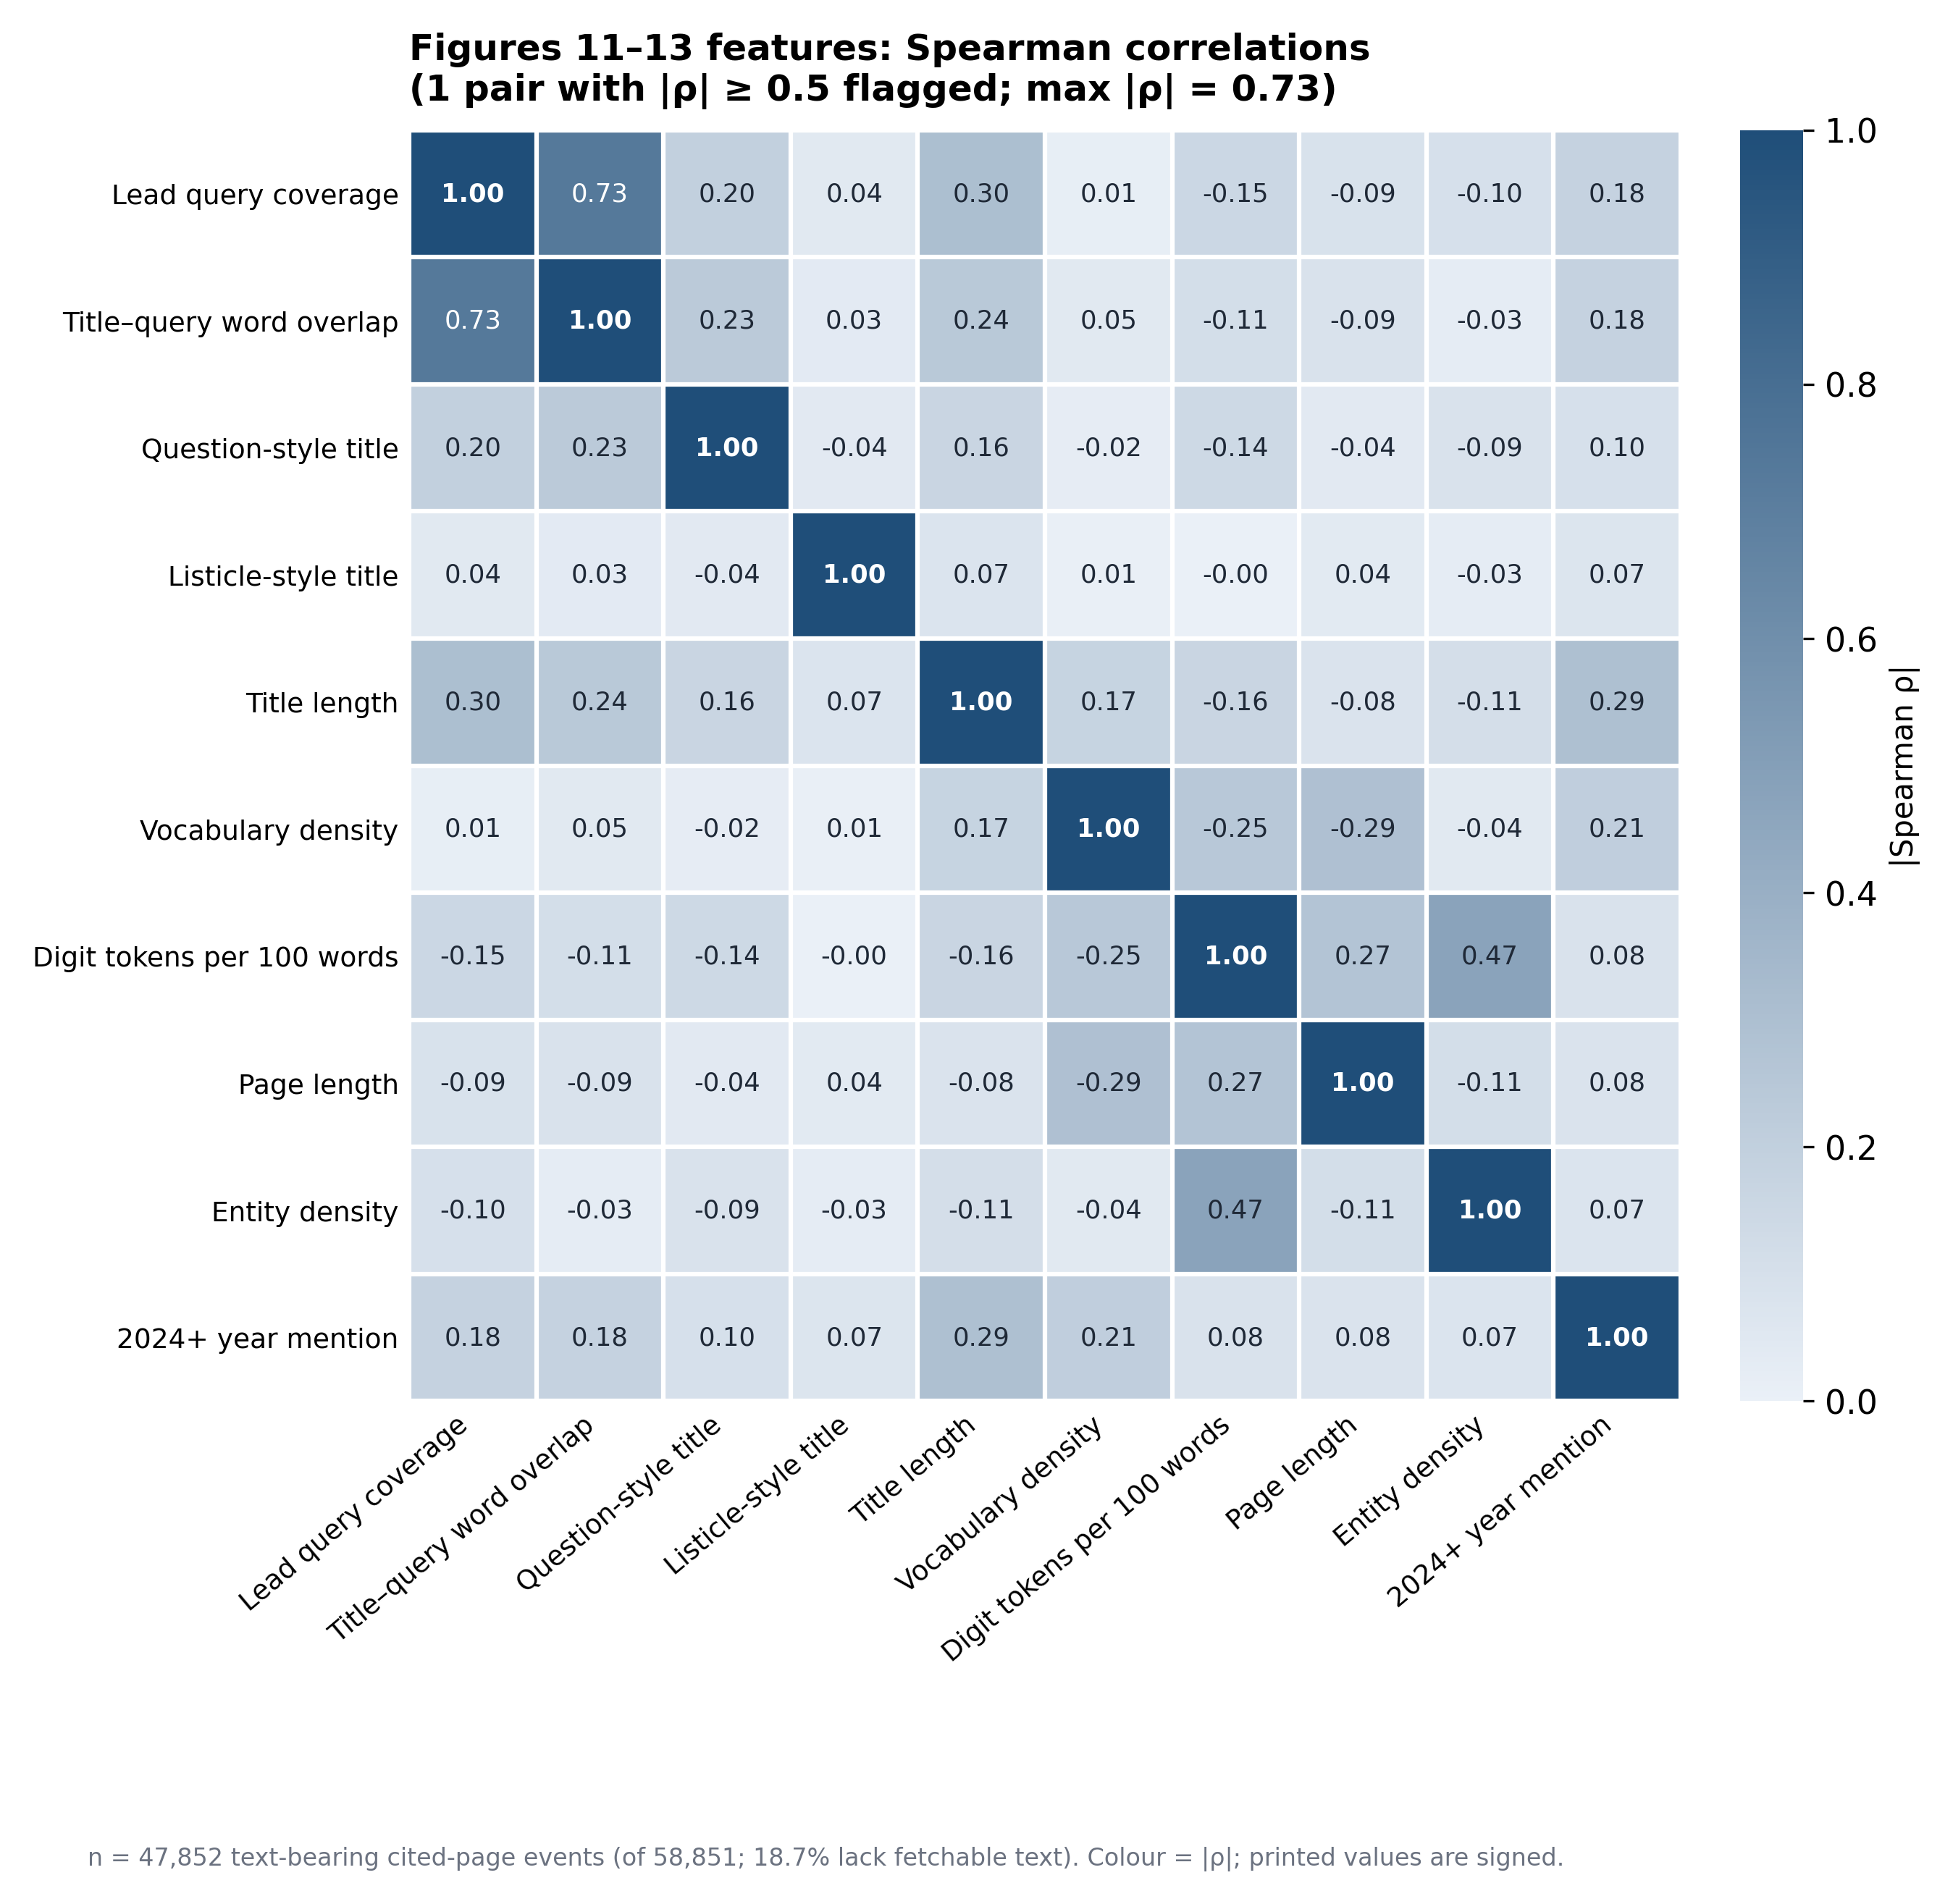

In [4]:
# C · 10x10 Spearman correlation matrix -> Word-ready table + heatmap (saved to figures/scaleup/). Flag |rho|>=0.5.
n = len(FEATS)
C = D[FEATS].corr(method="spearman")
labels = [LAB[c] for c in FEATS]
Cl = C.copy(); Cl.index = labels; Cl.columns = labels
print("Word-ready (tab-separated):")
print("\t" + "\t".join(labels))
for i, ri in enumerate(labels): print(ri + "\t" + "\t".join(f"{C.iloc[i, j]:.2f}" for j in range(n)))

flagged = [(labels[i], labels[j], C.iloc[i, j]) for i in range(n) for j in range(i + 1, n) if abs(C.iloc[i, j]) >= 0.5]
offdiag = sorted(((abs(C.iloc[i, j]), C.iloc[i, j], labels[i], labels[j])
                  for i in range(n) for j in range(i + 1, n)), reverse=True)
mx = offdiag[0]
print("\n|rho| >= 0.5 pairs needing a bundle-interpretation caveat:")
print("\n".join(f"  {a} <-> {b}: rho={r:+.2f}" for a, b, r in flagged) if flagged
      else f"  NONE — strongest off-diagonal |rho| = {mx[0]:.2f} ({mx[2]} <-> {mx[3]}).")

fig, ax = plt.subplots(figsize=(8.8, 7.6))
A = C.values.astype(float)
im = ax.imshow(np.abs(A), cmap=CMAP_SEQ, vmin=0, vmax=1, aspect="equal")
ax.set_xticks(range(n)); ax.set_xticklabels(labels, rotation=40, ha="right", fontsize=9)
ax.set_yticks(range(n)); ax.set_yticklabels(labels, fontsize=9)
for i in range(n):
    for j in range(n):
        v = A[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8.5,
                color="white" if abs(v) > 0.55 else "#1F2937", fontweight="bold" if i == j else "normal")
for sp in ax.spines.values(): sp.set_visible(False)
ax.set_xticks(np.arange(-.5, n, 1), minor=True); ax.set_yticks(np.arange(-.5, n, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.5); ax.tick_params(which="both", length=0)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cb.set_label("|Spearman ρ|", fontsize=10); cb.outline.set_visible(False)
_sub = (f"{len(flagged)} pair with |ρ| ≥ 0.5 flagged" if len(flagged) == 1 else
        (f"{len(flagged)} pairs with |ρ| ≥ 0.5 flagged" if flagged else "all |ρ| < 0.5 — features near-independent"))
ax.set_title(f"Figures 11–13 features: Spearman correlations\n({_sub}; max |ρ| = {mx[0]:.2f})",
             fontsize=12, fontweight="bold", loc="left", pad=10)
fig.text(0.0, -0.16, f"n = {len(D):,} text-bearing cited-page events (of {N_TOTAL:,}; 18.7% lack fetchable text). "
         "Colour = |ρ|; printed values are signed.", ha="left", va="top", fontsize=8, color="#6B7280")
base = "fig_pf_figure11_feature_spearman_corr"
for ext in ("png", "pdf"): fig.savefig(os.path.join(FIG_DIR, f"{base}.{ext}"))
print(f"\nsaved {base} -> figures/scaleup/")
plt.show()

**Interpretation.** Across the ten features, **one pair crosses the |ρ| ≥ 0.5 bar: lead query coverage ↔ title–query
word overlap (ρ = +0.73)** — unsurprisingly, since both measure how much a page reuses the query's words (in the opening
text versus the title). These two should be read as **one "lexical query-match" lever**, not two independent dials: the
support and re-citation models that include both are effectively splitting a single signal, so their individual
coefficients are best interpreted together. Every other pair sits well below the threshold — the next-strongest are digit
tokens per 100 words ↔ entity density (ρ = +0.47, number- and name-dense reference prose co-occurring) and lead query
coverage ↔ title length (ρ = +0.30) — and the known length bundle from the main text (vocabulary density ↔ page length,
ρ = −0.29) also stays modest here. So of the ten Figure 11–13 levers, only the two query-match features need a
bundle-interpretation caveat; the remaining eight can be read as independent signals.